# CheMeleon + Mother Standalone Heads

**Goal:** Use a pretrained molecular foundation model ([CheMeleon](https://github.com/chemprop/chemprop)) to
extract 2 048-dimensional molecular fingerprints, then plug them straight into
Mother's lightweight standalone heads for property prediction **with uncertainty
estimation**.

```
                        ┌──────────────────────────────────┐
  SMILES                │         CheMeleon                │
  "CCO"  ──────────►    │  Bond-Message-Passing Network    │
  "c1ccccc1"            │  (depth=6, d_h=2048, pretrained) │
                        └──────────────┬───────────────────┘
                                       │
                                       ▼
                               Fingerprints  (n, 2048)
                                       │
                    ┌──────────────────┼──────────────────┐
                    ▼                  ▼                  ▼
             ┌────────────┐   ┌──────────────┐   ┌──────────────┐
             │MLPHead     │   │FlowHead      │   │ NODERegressor│
             │Regressor   │   │Regressor     │   │ (+ MLP head) │
             │            │   │              │   │              │
             │ ŷ ∈ ℝ      │   │ p(y|x)       │   │ Trees → MLP  │
             │ + MC σ     │   │ + NLL σ      │   │ + MC σ       │
             └────────────┘   └──────────────┘   └──────────────┘
```

| Component | Role |
|---|---|
| **CheMeleon** | Pretrained Bond-Message-Passing Network (d_h = 2048, depth = 6). Converts SMILES → fixed-length molecular embeddings. |
| **MLPHeadRegressor** | Fast MLP head with MC-Dropout uncertainty (epistemic). |
| **FlowHeadRegressor** | Normalising-flow head that models the full p(y|x) distribution (aleatoric + epistemic). |

> **Why standalone heads?**  They accept any `(n, d)` NumPy / pandas feature
> matrix, so you can swap CheMeleon for **any** featuriser (Morgan FPs, Uni-Mol,
> MolBERT, …) without touching the downstream code.

> ⚠️ **This notebook is an illustrative example only.** The configurations below —
> especially the **NODE** and **Flow** heads — are deliberately small, run for only a
> few epochs, and are **not tuned**. They demonstrate the *API and workflow*, not
> competitive accuracy. Realistic use of NODE and Flow heads needs substantially
> **more hyperparameter tuning, more epochs, more data, and more compute (ideally a
> GPU)**. Do not read the metrics here as representative of what these models achieve.

## 1 — Import Required Libraries

In [1]:
import warnings

warnings.filterwarnings("ignore")  # suppress rdkit / numpy ABI noise

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from mother.feature_generation import CheMeleonFingerprintFactory
from mother.ml.models.m_heads import FlowHeadRegressor, MLPHeadRegressor

## 2 — Create CheMeleon Fingerprint Factory

`CheMeleonFingerprintFactory` now uses the **current Chemprop API only**.
If no `checkpoint_path` is passed, Mother automatically downloads and caches the
official CheMeleon foundation weights on first use.

Then we build a CPU-friendly fingerprinter (smaller batch for lower memory).


In [2]:
factory = CheMeleonFingerprintFactory(
    output_dim=2048,
    batch_size=128,  # lower memory footprint on CPU
    device="cpu",
)
fingerprinter = factory.get_fingerprint_generator()

print(f"✓ CheMeleon fingerprint generator ready  (output dim: {factory.output_dim})")
print("✓ Using automatic CheMeleon checkpoint provisioning (download + cache on first run)")

✓ CheMeleon fingerprint generator ready  (output dim: 2048)
✓ Using automatic CheMeleon checkpoint provisioning (download + cache on first run)


## 3 — Load the FreeSolv Dataset

[FreeSolv](https://github.com/MobleyLab/FreeSolv) contains **experimental
hydration free energies** (ΔG_hydr in kcal/mol).  We use the 50-molecule
training subset shipped with Mother's examples.


In [3]:
df = pd.read_csv("../freesolv_train.csv")
smiles = df["smiles"].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles]
targets = df["expt"].values.astype(np.float32)

print(f"Dataset: {len(df)} molecules")
df[["iupac", "smiles", "expt"]].head(10)

Dataset: 50 molecules


,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21
5,"3,5-dimethylphenol",Cc1cc(cc(c1)O)C,-6.27
6,"2,3-dimethylbutane",CC(C)C(C)C,2.34
7,2-methylpentan-2-ol,CCCC(C)(C)O,-3.92
8,"1,2-dimethylcyclohexane",C[C@@H]1CCCC[C@@H]1C,1.58
9,butan-2-ol,CC[C@H](C)O,-4.62


## 4 — Extract CheMeleon Fingerprints

Now we simply `fit_transform` the RDKit molecules through our transformer.


In [4]:
mols_array = np.array(mols, dtype=object)
fingerprints = fingerprinter.fit_transform(mols_array)
print(f"✓ Fingerprint matrix shape: {fingerprints.shape}")  # (50, 2048)

✓ Fingerprint matrix shape: (50, 2048)


## 5 — Train / Test Split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(fingerprints, targets, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} molecules, Test: {X_test.shape[0]} molecules")
print(f"Feature dim: {X_train.shape[1]}")

Train: 40 molecules, Test: 10 molecules
Feature dim: 2048


---

## 6 — Example: MLP with CheMeleon

Mother's `MLPHeadRegressor` wraps a standard MLP with:
- **Automatic dimension detection** — no need to pass `input_dim`; a Skorch
  callback reads it from the first batch.
- **Early stopping & LR scheduling** — sensible defaults out of the box.
- **MC-Dropout uncertainty** via `predict_uncertainty()`.

```
  CheMeleon fingerprint (2048-d)
        │
        ▼
  ┌─────────────────────────────────────────┐
  │  Linear(2048 → 512) → BN → ReLU → Drop │
  │  Linear(512  → 256) → BN → ReLU → Drop │
  │  Linear(256  → 128) → BN → ReLU → Drop │
  │  Linear(128  →   1)                     │
  └─────────────────────┬───────────────────┘
                        │
                        ▼
                  ΔG_hydr (kcal/mol)
```

Training minimises the MSE loss:  
$\mathcal{L}_{\text{MLP}} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$


In [6]:
mlp = MLPHeadRegressor(
    hidden_dims=[384, 192, 96],
    dropout=0.10,
    max_epochs=180,
    lr=0.0025,
)
mlp.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       43.5815       34.8691  0.0025  0.2109
      2       31.5756       36.2376  0.0025  0.0159
      3       26.4187       36.2574  0.0025  0.0089
      4       22.6086       35.2711  0.0025  0.0117
      5       19.9326       34.4108  0.0025  0.0108
      6       16.0650       33.5321  0.0025  0.0117
      7       16.0854       32.8770  0.0025  0.0109
      8       14.4116       32.2028  0.0025  0.0119
      9       12.8541       31.7430  0.0025  0.0137
     10       12.8088       31.3442  0.0025  0.0113
     11       10.6134 

<class 'mother.ml.models.m_heads.MLPHeadRegressor'>[initialized](
  module_=MLPHead(
    (mlp): Sequential(
      (0): Linear(in_features=2048, out_features=384, bias=True)
      (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=384, out_features=192, bias=True)
      (5): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=192, out_features=96, bias=True)
      (9): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=96, out_features=1, bias=True)
    )
  ),
)

### 6.1 — Evaluate MLP Predictions


In [7]:
y_pred_mlp = mlp.predict(X_test)
rmse_mlp = root_mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"MLP Head — RMSE: {rmse_mlp:.3f} kcal/mol,  R²: {r2_mlp:.3f}")

MLP Head — RMSE: 2.065 kcal/mol,  R²: 0.507


### 6.2 — Uncertainty Estimation (MC Dropout)

`predict_uncertainty()` enables dropout at inference time and draws
`n_samples` stochastic forward passes.  The standard deviation across passes is
reported as **knowledge (epistemic) uncertainty**.

```
                          Same input x
                              │
        ┌─────────────────────┼─────────────────────┐
        ▼                     ▼                     ▼
  MLP (mask θ₁)        MLP (mask θ₂)   ...   MLP (mask θₙ)
        │                     │                     │
        ▼                     ▼                     ▼
       ŷ₁                   ŷ₂         ...        ŷₙ
        └─────────────────────┼─────────────────────┘
                              │
                    mean = (1/N) Σ ŷᵢ
                    σ    = std(ŷ₁ … ŷₙ)   ← epistemic uncertainty
```

$\hat{y} = \frac{1}{N}\sum_{i=1}^{N} f_{\theta_i}(x) \qquad \sigma_{\text{MC}} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(f_{\theta_i}(x) - \hat{y})^2}$


In [8]:
unc_mlp = mlp.predict_uncertainty(X_test, n_samples=100)
unc_mlp

,pred,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-2.264852,-2.305246,0.246096,None,0.246096
1,1.667439,1.591114,0.384081,None,0.384081
2,-1.762847,-1.827466,0.308592,None,0.308592
3,-2.049078,-2.105275,0.278208,None,0.278208
4,-5.069623,-5.079119,0.465940,None,0.465940
5,-1.096171,-1.134256,0.338082,None,0.338082
6,-4.608744,-4.693451,0.682998,None,0.682998
7,0.337200,0.243317,0.251663,None,0.251663
8,-7.545507,-7.450991,0.597567,None,0.597567
9,-0.081902,-0.121074,0.412715,None,0.412715


### 6.3 — Visualise: Parity Plot & Uncertainty vs Error


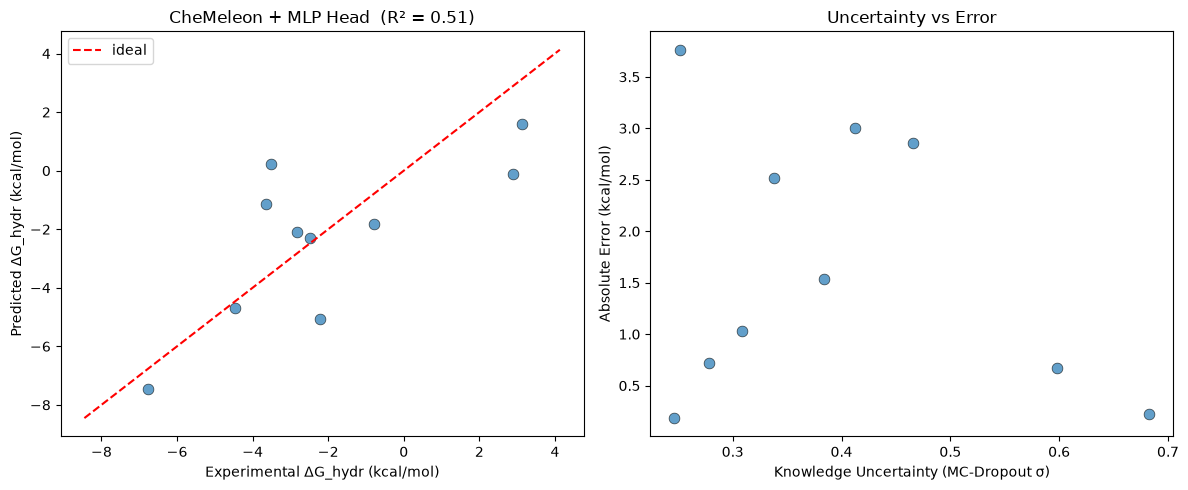

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Parity plot ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, unc_mlp["mean_predictions"], alpha=0.7, edgecolors="k", linewidths=0.5, s=60)
lims = [
    min(y_test.min(), unc_mlp["mean_predictions"].min()) - 1,
    max(y_test.max(), unc_mlp["mean_predictions"].max()) + 1,
]
ax.plot(lims, lims, "r--", lw=1.5, label="ideal")
ax.set_xlabel("Experimental ΔG_hydr (kcal/mol)")
ax.set_ylabel("Predicted ΔG_hydr (kcal/mol)")
ax.set_title(f"CheMeleon + MLP Head  (R² = {r2_mlp:.2f})")
ax.legend()

# ── Uncertainty vs absolute error ────────────────────────────
ax = axes[1]
errors = np.abs(y_test - unc_mlp["mean_predictions"].values)
ax.scatter(unc_mlp["knowledge_uncertainty"], errors, alpha=0.7, edgecolors="k", linewidths=0.5, s=60)
ax.set_xlabel("Knowledge Uncertainty (MC-Dropout σ)")
ax.set_ylabel("Absolute Error (kcal/mol)")
ax.set_title("Uncertainty vs Error")

plt.tight_layout()
plt.show()

---

## 6½ — NODE vs MLP Head: Side-by-Side Comparison

Mother's **NODERegressor** (Neural Oblivious Decision Ensembles) is a full
tree-based deep-learning model.  Here we feed it the same CheMeleon
fingerprints and compare against the lightweight standalone MLP head.

> ⚠️ **Example configuration only — not tuned.** The NODE settings below are tiny and
> train for only a handful of epochs so the notebook runs quickly on CPU. NODE is a
> heavy model that generally needs **more trees/depth/layers, many more epochs, proper
> hyperparameter tuning, more data, and ideally a GPU** to perform well. On this
> 40-molecule demo it will likely **underperform** the simple MLP head — that is
> expected and is *not* a fair reflection of NODE's real capability.

| | **NODERegressor** | **MLPHeadRegressor** |
|---|---|---|
| Architecture | Differentiable oblivious decision trees + head | Simple MLP |
| Parameters | `num_trees`, `depth`, `num_layers`, `head_type` | `hidden_dims`, `dropout` |
| Uncertainty | MC Dropout + optional Flow head | MC Dropout |
| Weight | Heavy (many trees) | Lightweight |


In [10]:
from mother.ml.models.m_node import NODERegressor

# NOTE: This is a deliberately small, UNTUNED example config chosen so the
# notebook runs fast on CPU. It is NOT expected to give good accuracy here.
# A realistic NODE model needs more trees/depth/layers, many more epochs,
# proper hyperparameter tuning, more data, and ideally a GPU.
node = NODERegressor(
    num_trees=512,
    depth=4,
    num_layers=1,
    head_type="mlp",
    mlp_hidden_dims=[128, 64],
    mlp_dropout=0.10,
    input_dropout=0.05,
    max_epochs=100,
    lr=0.005,
    batch_size=32,
)
node.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1       40.0066  3.8900
      2       28.5729  2.4816
      3       24.0836  2.5299
      4       16.8989  2.5976
      5       14.1133  2.5480
      6       11.9498  2.5036
      7        9.8642  2.4352
      8        8.4696  2.5078
      9        6.5408  2.4173
     10        7.9010  2.5138
     11        3.3792  2.3752
     12        4.0603  2.3225
     13        2.4628  2.1078
     14        3.0274  2.0524
     15        2.6955  2.1291
     16        3.5635  2.0973
     17        3.4183  2.1524
     18        2.7196  2.0852
     19        2.4103  2.0942
     20        2.5913  2.1126
     21        2.4362  2.0871
     22        2.3640  2.1398
     23        1.4154  2.0882
     24        1.0613  2.0620
     25        0.7503  2.1701
     26  

<class 'mother.ml.models.m_node.NODERegressor'>[initialized](
  module_=CompletePyTorchTabularNODE(
    (dense_block): DenseODSTBlock(
      (0): ODST(in_features=2048, num_trees=512, depth=4, tree_dim=4, flatten_output=True)
    )
    (embedding_layer): Embedding1dLayer()
    (head): MLPHead(
      (mlp): Sequential(
        (0): Linear(in_features=2048, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout(p=0.1, inplace=False)
        (8): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  ),
)

In [11]:
y_pred_node = node.predict(X_test)
rmse_node = root_mean_squared_error(y_test, y_pred_node)
r2_node = r2_score(y_test, y_pred_node)
print(f"NODE       — RMSE: {rmse_node:.3f} kcal/mol,  R²: {r2_node:.3f}")
print(f"MLP Head   — RMSE: {rmse_mlp:.3f} kcal/mol,  R²: {r2_mlp:.3f}")

NODE       — RMSE: 2.357 kcal/mol,  R²: 0.358
MLP Head   — RMSE: 2.065 kcal/mol,  R²: 0.507


### 6½.1 — NODE Uncertainty


In [12]:
unc_node = node.predict_uncertainty(X_test, num_samples=100)
unc_node

,pred,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-2.687978,-2.687978,0.446317,None,0.446317
1,2.239686,2.239686,0.482910,None,0.482910
2,-2.221553,-2.221553,0.398229,None,0.398229
3,-2.492616,-2.492616,0.408684,None,0.408684
4,-6.139686,-6.139686,0.625039,None,0.625039
5,-1.560854,-1.560854,0.427247,None,0.427247
6,-4.147614,-4.147614,0.714532,None,0.714532
7,0.543144,0.543144,0.251319,None,0.251319
8,-8.371608,-8.371608,0.828887,None,0.828887
9,-0.823289,-0.823289,0.443535,None,0.443535


### 6½.2 — Visual Comparison: NODE vs MLP Head


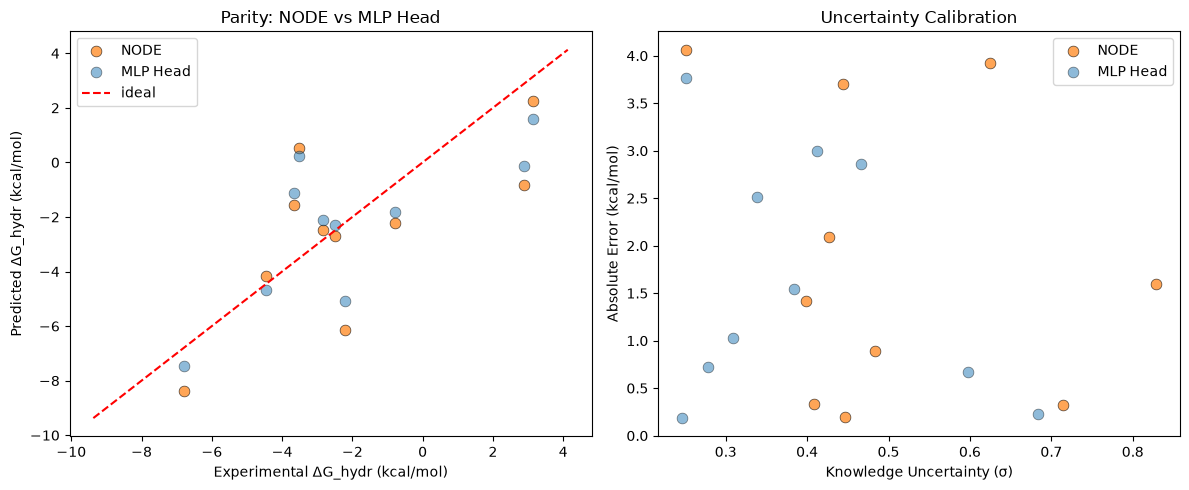

,Model,RMSE,R²,Mean σ
0,MLPHeadRegressor,2.065,0.507,0.397
1,NODERegressor,2.357,0.358,0.503


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── NODE parity ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    y_test,
    unc_node["mean_predictions"],
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:orange",
    label="NODE",
)
ax.scatter(
    y_test,
    unc_mlp["mean_predictions"],
    alpha=0.5,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:blue",
    label="MLP Head",
)
all_vals = np.concatenate([y_test, unc_node["mean_predictions"].values, unc_mlp["mean_predictions"].values])
lims = [all_vals.min() - 1, all_vals.max() + 1]
ax.plot(lims, lims, "r--", lw=1.5, label="ideal")
ax.set_xlabel("Experimental ΔG_hydr (kcal/mol)")
ax.set_ylabel("Predicted ΔG_hydr (kcal/mol)")
ax.set_title("Parity: NODE vs MLP Head")
ax.legend()

# ── Uncertainty comparison ───────────────────────────────────
ax = axes[1]
errors_node = np.abs(y_test - unc_node["mean_predictions"].values)
errors_mlp = np.abs(y_test - unc_mlp["mean_predictions"].values)
ax.scatter(
    unc_node["knowledge_uncertainty"],
    errors_node,
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:orange",
    label="NODE",
)
ax.scatter(
    unc_mlp["knowledge_uncertainty"],
    errors_mlp,
    alpha=0.5,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:blue",
    label="MLP Head",
)
ax.set_xlabel("Knowledge Uncertainty (σ)")
ax.set_ylabel("Absolute Error (kcal/mol)")
ax.set_title("Uncertainty Calibration")
ax.legend()

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────
comparison = pd.DataFrame(
    [
        {
            "Model": "MLPHeadRegressor",
            "RMSE": rmse_mlp,
            "R²": r2_mlp,
            "Mean σ": unc_mlp["knowledge_uncertainty"].mean(),
        },
        {
            "Model": "NODERegressor",
            "RMSE": rmse_node,
            "R²": r2_node,
            "Mean σ": unc_node["knowledge_uncertainty"].mean(),
        },
    ]
).round(3)
comparison

---

## 7 — Example: Flow with CheMeleon

The `FlowHeadRegressor` uses a **conditional normalising flow** to model the
full distribution $p(y \mid x)$.  This provides both aleatoric (data) and
epistemic (knowledge) uncertainty in a single model.

> ⚠️ **Example configuration only — not tuned.** Normalising flows are data-hungry
> and sensitive to hyperparameters. The small flow trained below on ~40 molecules is
> purely to demonstrate the API; it is expected to **overfit and underperform**. Good
> results require **more data, more tuning, more epochs, and more compute (ideally a
> GPU)**.

```
  CheMeleon fp (2048-d)  ──context──►  Neural Spline Flow (3 transforms)
                                              │
                                       z ~ N(0,1)
                                              │
                                       ┌──────┴──────┐
                                       │  T₁ (spline)│
                                       │  T₂ (spline)│
                                       │  T₃ (spline)│
                                       └──────┬──────┘
                                              │
                                              ▼
                                    y ~ p(y | x)  ← learned distribution
                                              │
                                     ┌────────┴────────┐
                                     │ .sample(600)    │ → histogram of ΔG
                                     │ .log_prob(y)    │ → NLL uncertainty
                                     └─────────────────┘
```

The training loss is the **negative log-likelihood** under the change-of-variables formula.
We use **Neural Spline Flows (NSF)** — flexible and stable for small datasets.


In [14]:
flow = FlowHeadRegressor(
    flow_type="NSF",
    flow_transforms=3,
    flow_bins=8,
    max_epochs=120,
    lr=0.0015,
)
flow.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: context_activation, context_dropout, context_hidden_dims, flow_bins, flow_components, flow_degree, flow_signal, flow_transforms, flow_type, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       21.6565       10.7292  0.0015  0.0725
      2       21.3162       10.1488  0.0015  0.0553
      3       21.0330        9.5058  0.0015  0.0349
      4       20.7474        8.8066  0.0015  0.0257
      5       20.4392        7.9822  0.0015  0.0279
      6       20.0931        7.1304  0.0015  0.0222
      7       19.7870        6.5855  0.0015  0.0224
      8       19.5167        6.3467  0.0015  0.0264
      9       19.2514        6.1

<class 'mother.ml.models.m_heads.FlowHeadRegressor'>[initialized](
  module_=FlowHead(
    (context_net): Identity()
    (net): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=2048, out_features=64, bias=True)
            (1): ReLU()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
    )
  ),
)

### 7.1 — Flow Predictions & Uncertainty


In [15]:
unc_flow = flow.predict_uncertainty(X_test, num_samples=300)

y_pred_flow = unc_flow["mean_predictions"].values
rmse_flow = root_mean_squared_error(y_test, y_pred_flow)
r2_flow = r2_score(y_test, y_pred_flow)

print(f"Flow Head — RMSE: {rmse_flow:.3f} kcal/mol,  R²: {r2_flow:.3f}")
unc_flow

Flow Head — RMSE: 3.289 kcal/mol,  R²: -0.251


,pred,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-4.703971,-4.703971,None,0.299699,0.299699
1,2.171289,2.171289,None,-0.979524,-0.979524
2,-2.266685,-2.266685,None,0.867570,0.867570
3,-4.742678,-4.742678,None,-0.238555,-0.238555
4,-4.680020,-4.680020,None,0.507804,0.507804
5,1.360105,1.360105,None,0.503371,0.503371
6,-4.894430,-4.894430,None,-2.444895,-2.444895
7,-4.762129,-4.762129,None,-0.022741,-0.022741
8,-4.689953,-4.689953,None,0.315062,0.315062
9,-4.821446,-4.821446,None,-0.420001,-0.420001


> **Note:** The flow head learns the *full conditional distribution* p(y | x),
> which requires more data than a simple MLP point-predictor.  With only 40
> training molecules and 2 048 features, overfitting is expected.  On larger
> datasets (≥ 200 molecules) flow heads typically match or surpass MLP heads
> while providing richer uncertainty estimates.

### 7.2 — Sampling from the Predictive Distribution

The Flow head can also **sample** from $p(y \mid x)$ directly, giving you full
posterior predictive distributions per molecule.

For each molecule $x_i$, we draw $M$ samples and can compute any statistic:

$$y_i^{(1)}, \ldots, y_i^{(M)} \sim p(y \mid x_i)$$

$$\hat{y}_i = \text{mode}\bigl(y_i^{(1..M)}\bigr) \qquad \text{CI}_{95\%} = \bigl[Q_{0.025},\; Q_{0.975}\bigr]$$


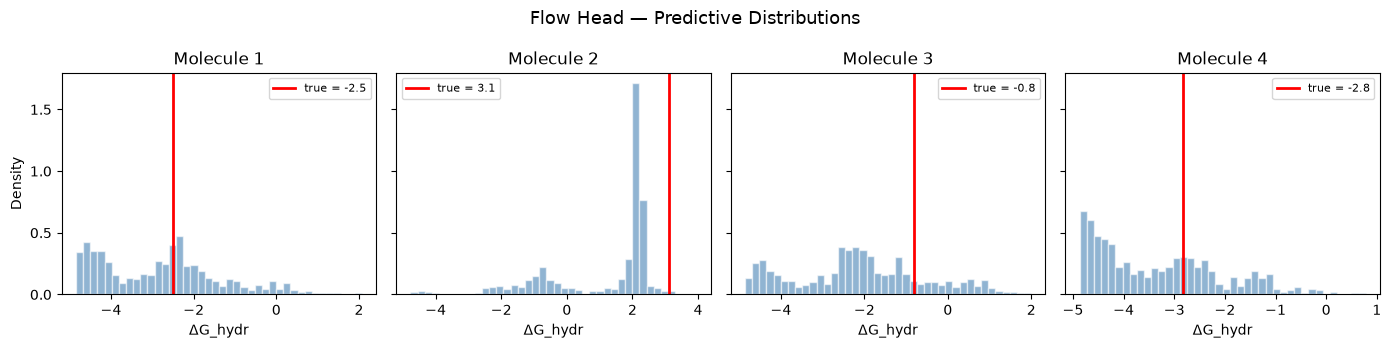

In [16]:
# Draw 600 samples per test molecule → shape (n_test, 600, 1)
samples = flow.predict_flow(X_test, num_samples=600)

# Visualise predictive distributions for first 4 test molecules
fig, axes = plt.subplots(1, min(4, len(y_test)), figsize=(14, 3.5), sharey=True)
for i, ax in enumerate(axes):
    s = samples[i, :, 0]
    ax.hist(s, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
    ax.set_title(f"Molecule {i + 1}")
    ax.set_xlabel("ΔG_hydr")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("Flow Head — Predictive Distributions", fontsize=13)
plt.tight_layout()
plt.show()

---

## 7½ — NODE + Flow Head: Tree Embeddings with Probabilistic Output

`NODERegressor` also supports **`head_type="flow"`**, which replaces the
final MLP head with a normalising flow.  This combines NODE's powerful
tree-based feature extraction with a full conditional density estimator:

```
  CheMeleon fp (2048-d)
        │
  ┌─────┴──────────────────────────────┐
  │  NODE: Oblivious Decision Trees     │
  │  (192 trees, depth 4, 1 layer)      │
  └─────┬──────────────────────────────┘
        │  tree embeddings
  ┌─────┴──────────────────────────────┐
  │  NSF Flow (3 transforms)           │
  │       p(y | tree_embed)            │
  └─────┬──────────────────────────────┘
        │
   point prediction + uncertainty
```

| Uncertainty source | Mechanism |
|---|---|
| **Epistemic** (knowledge) | Input dropout during MC-Dropout inference |
| **Aleatoric** (data) | Flow distribution width per molecule |
| **Total** | Combined from both sources |

> **CPU middle-ground:** this setup is tuned for laptop/CPU runs.
> It is stronger than the tiny demo config (better fit quality),
> while staying moderate in memory/time compared with very large models.

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1       19.8179  1.4959
      2       18.1176  1.0826
      3       17.8487  1.0601
      4       17.9446  1.0354
      5       17.6800  1.0239
      6       17.9301  1.5166
      7       17.6770  1.0160
      8       17.6410  1.0409
      9       17.6004  1.0852
     10       17.6316  0.9622
     11       17.4766  1.1114
     12       17.5265  1.0314
     13       17.2332  1.0171
     14       17.2663  1.2971
     15       17.1094  1.0139
     16       16.9516  1.0160
     17       17.1425  1.0562
     18       16.9264  1.0479
     19       16.8505  1.0256
     20       17.0135  1.1013
     21       16.8890  1.0601
     22       16.7786  1.0495
     23       16.6847  0.9780
     24       16.6404  1.0591
     25       16.4341  1.1244
     26  

,pred,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-3.976528,-3.976528,0.049397,-1.190298,-1.140902
1,2.021033,2.021033,0.008865,-0.990503,-0.981638
2,-3.387832,-3.387832,0.084521,0.465533,0.550054
3,-3.280733,-3.280733,0.023415,0.433557,0.456972
4,-4.324215,-4.324215,0.007855,-1.045035,-1.037180
5,-3.832166,-3.832166,0.104566,-0.916472,-0.811906
6,-3.902314,-3.902314,0.091168,-0.340678,-0.249510
7,-3.052826,-3.052826,0.087509,0.698624,0.786134
8,-4.641998,-4.641998,0.008888,-1.620027,-1.611140
9,1.540580,1.540580,0.010051,0.366682,0.376732


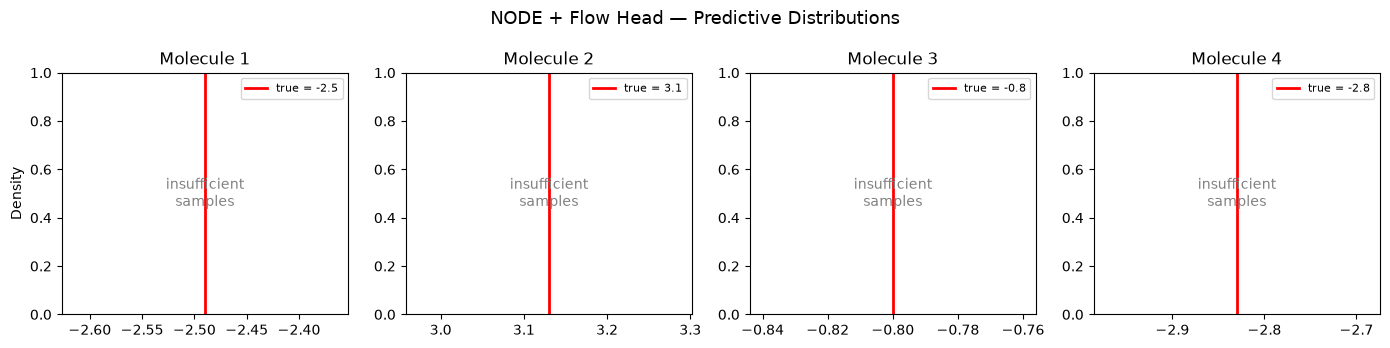

In [17]:
import gc
import torch

# Free ALL earlier models + the fingerprinter to reclaim as much RAM as possible
for _v in ("mlp", "flow", "node", "fingerprinter", "factory"):
    if _v in dir():
        exec(f"del {_v}")
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ── Train ────────────────────────────────────────────────────────────────
# Balanced CPU-friendly setup: stronger than the tiny config without
# jumping to very heavy tree/flow sizes.
node_flow = NODERegressor(
    num_trees=192,
    depth=4,
    num_layers=1,
    head_type="flow",
    flow_type="NSF",
    flow_transforms=3,
    flow_bins=8,
    input_dropout=0.03,
    max_epochs=120,
    lr=0.003,
    batch_size=16,
)
node_flow.fit(X_train, y_train)

# ── Point predictions ────────────────────────────────────────────────────
y_pred_node_flow = node_flow.predict(X_test)
rmse_nf = root_mean_squared_error(y_test, y_pred_node_flow)
r2_nf = r2_score(y_test, y_pred_node_flow)
print(f"NODE+Flow  — RMSE: {rmse_nf:.3f} kcal/mol,  R²: {r2_nf:.3f}")
print(f"NODE+MLP   — RMSE: {rmse_node:.3f} kcal/mol,  R²: {r2_node:.3f}")
print(f"Flow Head  — RMSE: {rmse_flow:.3f} kcal/mol,  R²: {r2_flow:.3f}")

# ── Uncertainty ──────────────────────────────────────────────────────────
print("\n— Uncertainty estimates —")
unc_node_flow = node_flow.predict_uncertainty(X_test, num_samples=30)
display(unc_node_flow)

# ── Sample from the flow head ────────────────────────────────────────────
from scipy.stats import gaussian_kde

samples_nf = node_flow.predict_flow_head(X_test, num_samples=300)

fig, axes = plt.subplots(1, min(4, len(y_test)), figsize=(14, 3.5))
for i, ax in enumerate(axes):
    s = np.asarray(samples_nf[i]).ravel()  # works for 2-D or 3-D output
    # Need at least 2 unique values for KDE / histogram
    s = s[np.isfinite(s)]
    if len(s) < 2:
        ax.text(
            0.5,
            0.5,
            "insufficient\nsamples",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=10,
            color="grey",
        )
        ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
        ax.set_title(f"Molecule {i + 1}")
        ax.legend(fontsize=8)
        continue
    spread = max(np.ptp(s), 0.5)  # ensure visible x-range
    lo, hi = s.min() - 0.3 * spread, s.max() + 0.3 * spread
    # KDE handles very narrow distributions better than histograms
    try:
        if len(np.unique(s)) < 2:
            raise np.linalg.LinAlgError("constant samples")
        kde = gaussian_kde(s, bw_method=0.3)
        xs = np.linspace(lo, hi, 300)
        ax.fill_between(xs, kde(xs), alpha=0.5, color="darkorange")
        ax.plot(xs, kde(xs), color="darkorange", lw=1.5)
    except (np.linalg.LinAlgError, ValueError):
        ax.hist(s, bins=30, density=True, alpha=0.6, color="darkorange")
    ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
    ax.axvline(np.median(s), color="darkorange", ls="--", lw=1.5, label=f"median = {np.median(s):.1f}")
    ax.set_xlim(lo, hi)
    ax.set_title(f"Molecule {i + 1}")
    ax.set_xlabel("ΔG_hydr")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("NODE + Flow Head — Predictive Distributions", fontsize=13)
plt.tight_layout()
plt.show()

# ── Free the heavy model immediately ─────────────────────────────────────
del node_flow, samples_nf, unc_node_flow
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

---

## 9 — Experiment: Different MLP Architectures

Because the standalone heads are just scikit-learn estimators, it's easy to
sweep over architectures.

In [18]:
import gc
import torch

configs = {
    "compact": {"hidden_dims": [192, 96], "dropout": 0.08, "max_epochs": 120},
    "balanced": {"hidden_dims": [384, 192, 96], "dropout": 0.10, "max_epochs": 150},
    "balanced_plus": {"hidden_dims": [512, 256, 128], "dropout": 0.12, "max_epochs": 160},
}

results = []
for name, cfg in configs.items():
    cfg_local = dict(cfg)
    epochs = cfg_local.pop("max_epochs")
    m = MLPHeadRegressor(max_epochs=epochs, lr=0.0025, **cfg_local)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    results.append(
        {
            "config": name,
            "hidden_dims": cfg_local["hidden_dims"],
            "dropout": cfg_local["dropout"],
            "max_epochs": epochs,
            "RMSE": root_mean_squared_error(y_test, yp),
            "R²": r2_score(y_test, yp),
        }
    )
    # Free the model immediately to avoid OOM on 8 GB machines
    del m
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

pd.DataFrame(results).round(3)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       41.3599       33.1333  0.0025  0.0087
      2       30.7548       32.8883  0.0025  0.0097
      3       27.2467       32.3244  0.0025  0.0132
      4       23.7186       31.5828  0.0025  0.0154
      5       20.7868       30.8072  0.0025  0.0085
      6       18.4584       30.0330  0.0025  0.0072
      7       16.5254       29.1484  0.0025  0.0082
      8       16.6488       28.3900  0.0025  0.0089
      9       13.9477       27.4702  0.0025  0.0070
     10       12.6278       26.5206  0.0025  0.0064
     11       12.5891 

,config,hidden_dims,dropout,max_epochs,RMSE,R²
0,compact,"[192, 96]",0.08,120,2.207,0.437
1,balanced,"[384, 192, 96]",0.10,150,2.019,0.529
2,balanced_plus,"[512, 256, 128]",0.12,160,2.158,0.462


---

## Summary

```
  SMILES  ──►  RDKit Mols  ──►  CheMeleon  ──►  Fingerprints (2048-d)  ──►  Head  ──►  ŷ + σ
                                (frozen)         (any featuriser)           (train)

                                                         ┌──────────────────────┐
                                                         │ MLPHead      → ŷ, σ_MC│
                                                         │ FlowHead    → p(y|x) │
                                                         │ NODE+MLP    → ŷ, σ_MC│
                                                         │ NODE+Flow   → p(y|x) │
                                                         └──────────────────────┘
```

| Step | What happens |
|---|---|
| **`CheMeleonFingerprintFactory`** | Loads the provided Chemprop checkpoint (`checkpoint_path`) and builds a fingerprint generator |
| **`CheMeleonFingerprinter`** | Sklearn transformer: RDKit molecules → 2 048-dim pretrained molecular embeddings |
| **`MLPHeadRegressor`** | MLP + early stopping + LR schedule; `predict_uncertainty()` via MC Dropout |
| **`NODERegressor(head_type="mlp")`** | NODE trees + MLP head; MC Dropout uncertainty |
| **`NODERegressor(head_type="flow")`** | NODE trees + normalising flow; full p(y\|x) + epistemic/aleatoric uncertainty |
| **`FlowHeadRegressor`** | Standalone normalising flow; `predict_flow()` for full p(y\|x) sampling |
| **Plug-and-play** | Swap CheMeleon for **any** `(n, d)` featuriser — Morgan FPs, Uni-Mol, MolBERT, … |

All models return a **standardised 4-column DataFrame**:

```
mean_predictions │ knowledge_uncertainty │ data_uncertainty │ total_uncertainty
```

making them directly compatible with Mother's cross-validation, optimisation,
and reporting pipelines.